In [94]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

In [95]:
dataset = pd.read_excel("./train_historical_data/2024_WEY2WAT.xlsx")
dataset.columns = dataset.columns.str.strip()
dataset = dataset.drop(columns=["late_canc_reason"], errors="ignore")
dataset["date_of_service"] = pd.to_datetime(dataset["date_of_service"])
dataset["location"] = dataset["location"].astype(str).str.strip().str.upper()
dataset["_row_order"] = np.arange(len(dataset))
all_station_codes = sorted(dataset["location"].dropna().unique())


def time_to_minutes(value):
    if pd.isna(value):
        return np.nan
    return value.hour * 60 + value.minute


def add_rollover_minutes(group, time_column):
    minutes = group[time_column].apply(time_to_minutes)
    rollover_days = 0
    previous_minute = np.nan
    absolute_minutes = []

    for minute in minutes:
        if pd.isna(minute):
            absolute_minutes.append(np.nan)
            continue

        if not pd.isna(previous_minute) and minute < previous_minute - (12 * 60):
            rollover_days += 1

        absolute_minutes.append(minute + (rollover_days * 24 * 60))
        previous_minute = minute

    return pd.Series(absolute_minutes, index=group.index)


dataset = dataset.sort_values(["rid", "_row_order"]).copy()
dataset["stop_number"] = dataset.groupby("rid").cumcount()
dataset["planned_arrival_minutes"] = dataset.groupby("rid", group_keys=False).apply(
    lambda group: add_rollover_minutes(group, "planned_arrival_time")
)
dataset["actual_arrival_minutes"] = dataset.groupby("rid", group_keys=False).apply(
    lambda group: add_rollover_minutes(group, "actual_arrival_time")
)
dataset["planned_departure_minutes"] = dataset.groupby("rid", group_keys=False).apply(
    lambda group: add_rollover_minutes(group, "planned_departure_time")
)
dataset["actual_departure_minutes"] = dataset.groupby("rid", group_keys=False).apply(
    lambda group: add_rollover_minutes(group, "actual_departure_time")
)

# Origin WEY has departure times but no arrival times. Other stops usually use arrival time.
dataset["current_planned_minutes"] = dataset["planned_arrival_minutes"].combine_first(
    dataset["planned_departure_minutes"]
)
dataset["current_actual_minutes"] = dataset["actual_arrival_minutes"].combine_first(
    dataset["actual_departure_minutes"]
)

wat_rows = dataset[dataset["location"] == "WAT"][[
    "rid",
    "stop_number",
    "planned_arrival_minutes",
    "actual_arrival_minutes",
]].rename(columns={
    "stop_number": "wat_stop_number",
    "planned_arrival_minutes": "planned_wat_minutes",
    "actual_arrival_minutes": "actual_wat_minutes",
})

model_data = dataset.merge(wat_rows, on="rid", how="inner")
model_data = model_data[model_data["stop_number"] <= model_data["wat_stop_number"]].copy()

model_data["current_delay"] = (
    model_data["current_actual_minutes"] - model_data["current_planned_minutes"]
)
model_data["planned_time_now"] = model_data["current_planned_minutes"] % (24 * 60)
model_data["remaining_minutes"] = (
    model_data["planned_wat_minutes"] - model_data["current_planned_minutes"]
)
model_data["stops_remaining"] = model_data["wat_stop_number"] - model_data["stop_number"]
model_data["day_of_week"] = model_data["date_of_service"].dt.dayofweek
model_data["y_final_delay"] = (
    model_data["actual_wat_minutes"] - model_data["planned_wat_minutes"]
)

model_data = model_data.dropna(subset=[
    "current_delay",
    "planned_time_now",
    "remaining_minutes",
    "stops_remaining",
    "day_of_week",
    "y_final_delay",
])

station_columns = pd.get_dummies(model_data["location"], prefix="station", dtype=int)
station_columns = station_columns.reindex(
    columns=[f"station_{station}" for station in all_station_codes], fill_value=0
)
model_data_with_ids = pd.concat([
    model_data[["rid"]],
    model_data[[
        "current_delay",
        "planned_time_now",
        "remaining_minutes",
        "stops_remaining",
        "day_of_week",
    ]],
    station_columns,
    model_data[["y_final_delay"]],
], axis=1)

model_data_with_ids = model_data_with_ids.astype(int)
model_data = model_data_with_ids.drop(columns=["rid"])
output_path = "./train_historical_data/wey2wat_modelling_data.csv"
model_data.to_csv(output_path, index=False)

print(f"Saved {len(model_data)} rows to {output_path}")
model_data.head()

Saved 135971 rows to ./train_historical_data/wey2wat_modelling_data.csv


,current_delay,planned_time_now,remaining_minutes,stops_remaining,day_of_week,station_ANF,station_BCU,station_BEU,station_BKO,station_BMH,...,station_UPW,station_WAT,station_WEY,station_WIM,station_WIN,station_WNF,station_WOK,station_WOO,station_WRM,y_final_delay
0,0,656,183,19,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,-1,660,179,18,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,0,667,172,17,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,-2,675,164,16,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,680,159,15,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [96]:
# Keep WAT in the saved CSV, but exclude it when scoring predictive models.
# At WAT, current_delay is already the final delay, so including it leaks the answer.
training_data = model_data_with_ids[model_data_with_ids["station_WAT"] == 0].copy()

X = training_data.drop(columns=["rid", "y_final_delay"])
y = training_data["y_final_delay"]
groups = training_data["rid"]
# print("groups", groups)

# Split by train journey, not by row, so stops from the same train do not appear in both sets.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_index, test_index = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_index]
X_test = X.iloc[test_index]
y_train = y.iloc[train_index]
y_test = y.iloc[test_index]

print("Full training data:", X.shape, y.shape)
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Unique train journeys:", groups.iloc[train_index].nunique())
print("Unique test journeys:", groups.iloc[test_index].nunique())

Full training data: (128375, 47) (128375,)
Train: (102638, 47) (102638,)
Test: (25737, 47) (25737,)
Unique train journeys: 6076
Unique test journeys: 1519


## Train Linear Regression Model

model              Ridge Linear Regression
MAE_minutes                       5.274475
RMSE_minutes                      8.625703
R2                                0.327274
within_5_min                      0.632436
within_10_min                     0.900921
within_15_min                     0.953841
large_delay_MAE                  27.562812


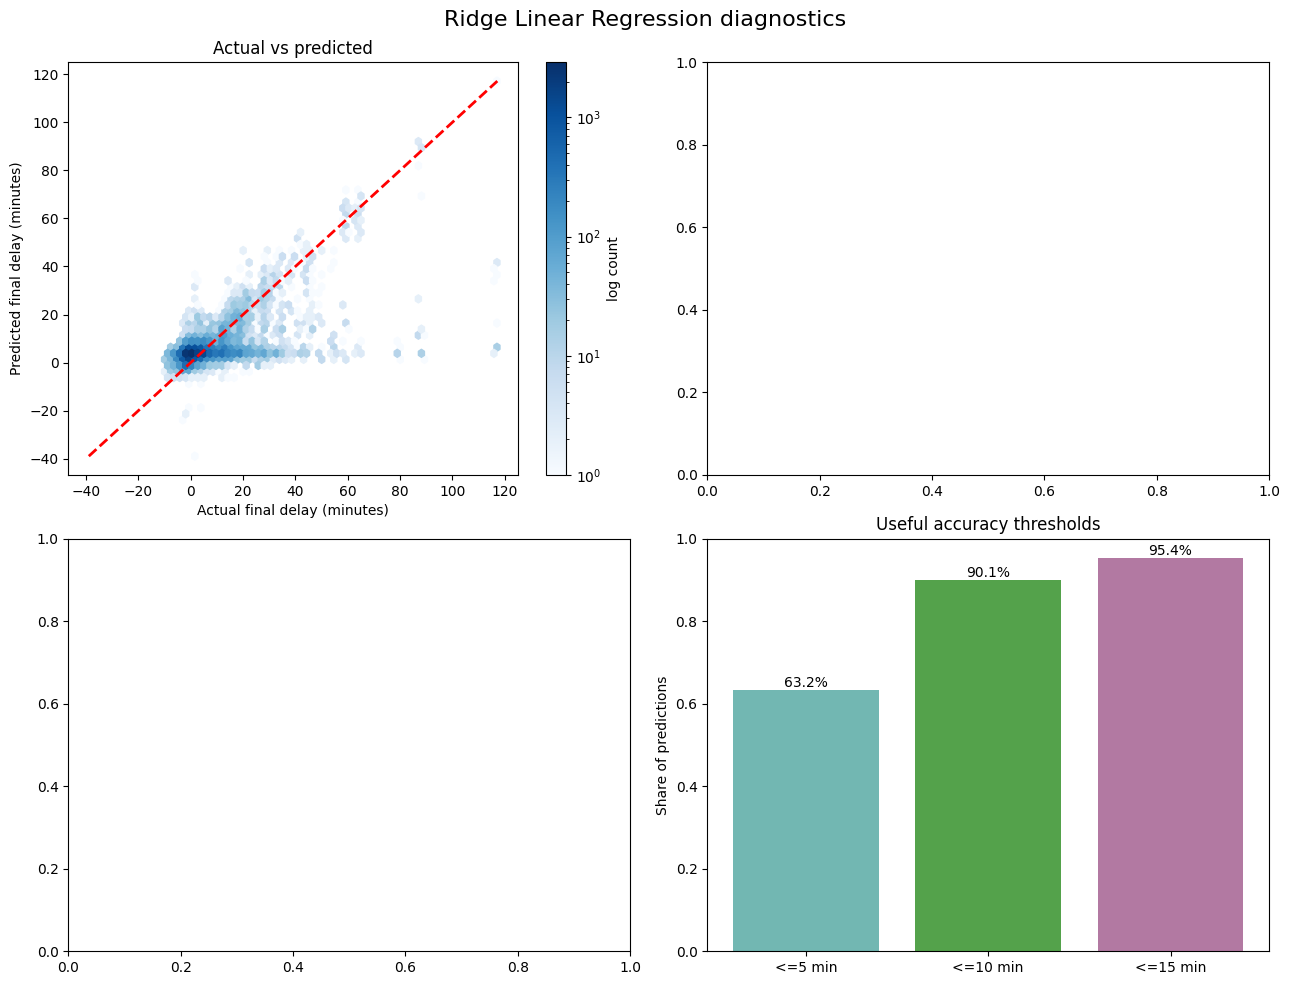

In [97]:
def regression_metrics(model_name, y_true, y_pred):
    errors = y_pred - y_true
    absolute_errors = np.abs(errors)
    y_true_array = np.asarray(y_true)
    large_delay_mask = y_true_array >= 30

    return {
        "model": model_name,
        "MAE_minutes": mean_absolute_error(y_true, y_pred),
        "RMSE_minutes": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "within_5_min": np.mean(absolute_errors <= 5),
        "within_10_min": np.mean(absolute_errors <= 10),
        "within_15_min": np.mean(absolute_errors <= 15),
        "large_delay_MAE": mean_absolute_error(y_true_array[large_delay_mask], y_pred[large_delay_mask]),
    }


def plot_regression_diagnostics(model_name, y_true, y_pred):
    errors = y_pred - y_true
    absolute_errors = np.abs(errors)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    actual_pred = axes[0, 0].hexbin(
        y_true,
        y_pred,
        gridsize=55,
        cmap="Blues",
        mincnt=1,
        bins="log",
    )
    axes[0, 0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
    axes[0, 0].set_xlabel("Actual final delay (minutes)")
    axes[0, 0].set_ylabel("Predicted final delay (minutes)")
    axes[0, 0].set_title("Actual vs predicted")
    fig.colorbar(actual_pred, ax=axes[0, 0], label="log count")

    # residuals = axes[0, 1].hexbin(
    #     y_true,
    #     errors,
    #     gridsize=55,
    #     cmap="Purples",
    #     mincnt=1,
    #     bins="log",
    # )
    # axes[0, 1].axhline(0, color="red", linestyle="--", lw=2)
    # axes[0, 1].set_xlabel("Actual final delay (minutes)")
    # axes[0, 1].set_ylabel("Prediction error (predicted - actual)")
    # axes[0, 1].set_title("Residuals")
    # fig.colorbar(residuals, ax=axes[0, 1], label="log count")

    # sns.histplot(errors, bins=60, ax=axes[1, 0], color="#4C78A8")
    # axes[1, 0].axvline(0, color="red", linestyle="--", lw=2)
    # axes[1, 0].set_xlabel("Prediction error (minutes)")
    # axes[1, 0].set_title("Error distribution")

    threshold_labels = ["<=5 min", "<=10 min", "<=15 min"]
    threshold_values = [
        np.mean(absolute_errors <= 5),
        np.mean(absolute_errors <= 10),
        np.mean(absolute_errors <= 15),
    ]
    axes[1, 1].bar(threshold_labels, threshold_values, color=["#72B7B2", "#54A24B", "#B279A2"])
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].set_ylabel("Share of predictions")
    axes[1, 1].set_title("Useful accuracy thresholds")
    for index, value in enumerate(threshold_values):
        axes[1, 1].text(index, value, f"{value:.1%}", ha="center", va="bottom")

    fig.suptitle(f"{model_name} diagnostics", fontsize=16)
    fig.tight_layout()
    plt.show()


model_scores = []

# Ridge is still a linear regression model, but regularisation makes it more stable
# with many one-hot station columns than plain LinearRegression.
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0)),
])
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_metrics = regression_metrics("Ridge Linear Regression", y_test, linear_pred)
model_scores.append(linear_metrics)
print(pd.Series(linear_metrics).to_string())
plot_regression_diagnostics("Ridge Linear Regression", y_test, linear_pred)

## Train Histogram Gradient Boosting Model

model              HistGradientBoosting
MAE_minutes                    5.064472
RMSE_minutes                    8.30899
R2                             0.375768
within_5_min                   0.674399
within_10_min                   0.90263
within_15_min                  0.949489
large_delay_MAE               25.789294


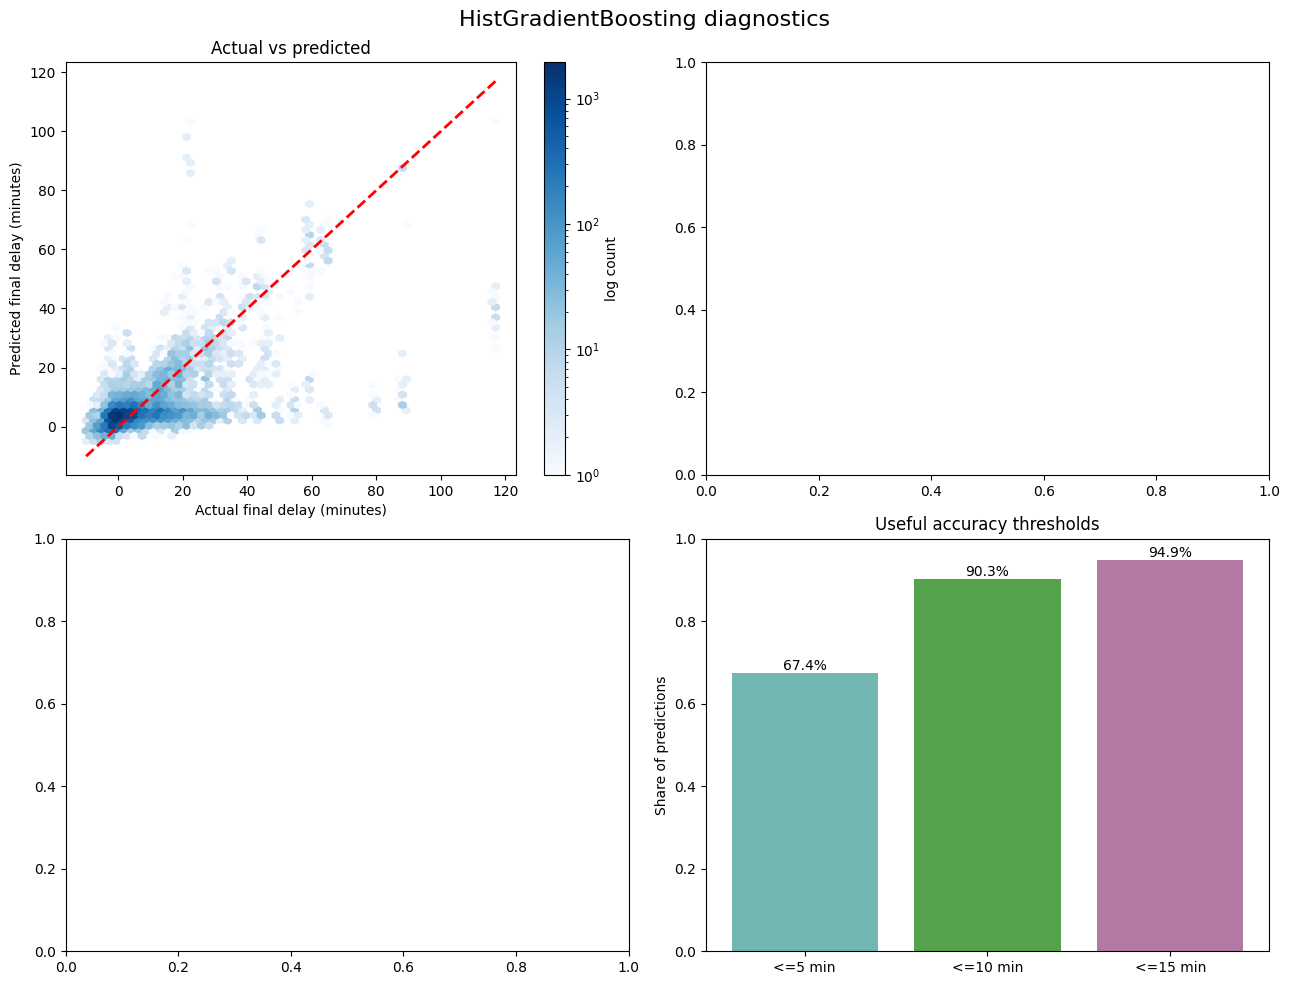

In [98]:
# Gradient boosting handles non-linear relationships between station, current delay,
# remaining time, and final delay better than a straight-line model.
# I tested a weighted version for rare severe delays, but it reduced overall MAE/RMSE,
# so this unweighted version is the better default comparison model.
hist_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    random_state=42,
)
hist_model.fit(X_train, y_train)
hist_pred = hist_model.predict(X_test)

hist_metrics = regression_metrics("HistGradientBoosting", y_test, hist_pred)
model_scores.append(hist_metrics)
print(pd.Series(hist_metrics).to_string())
plot_regression_diagnostics("HistGradientBoosting", y_test, hist_pred)

## Train KNN Model

model                    KNN
MAE_minutes         5.515518
RMSE_minutes        9.335784
R2                  0.211955
within_5_min        0.653922
within_10_min       0.856044
within_15_min       0.929751
large_delay_MAE    27.231577


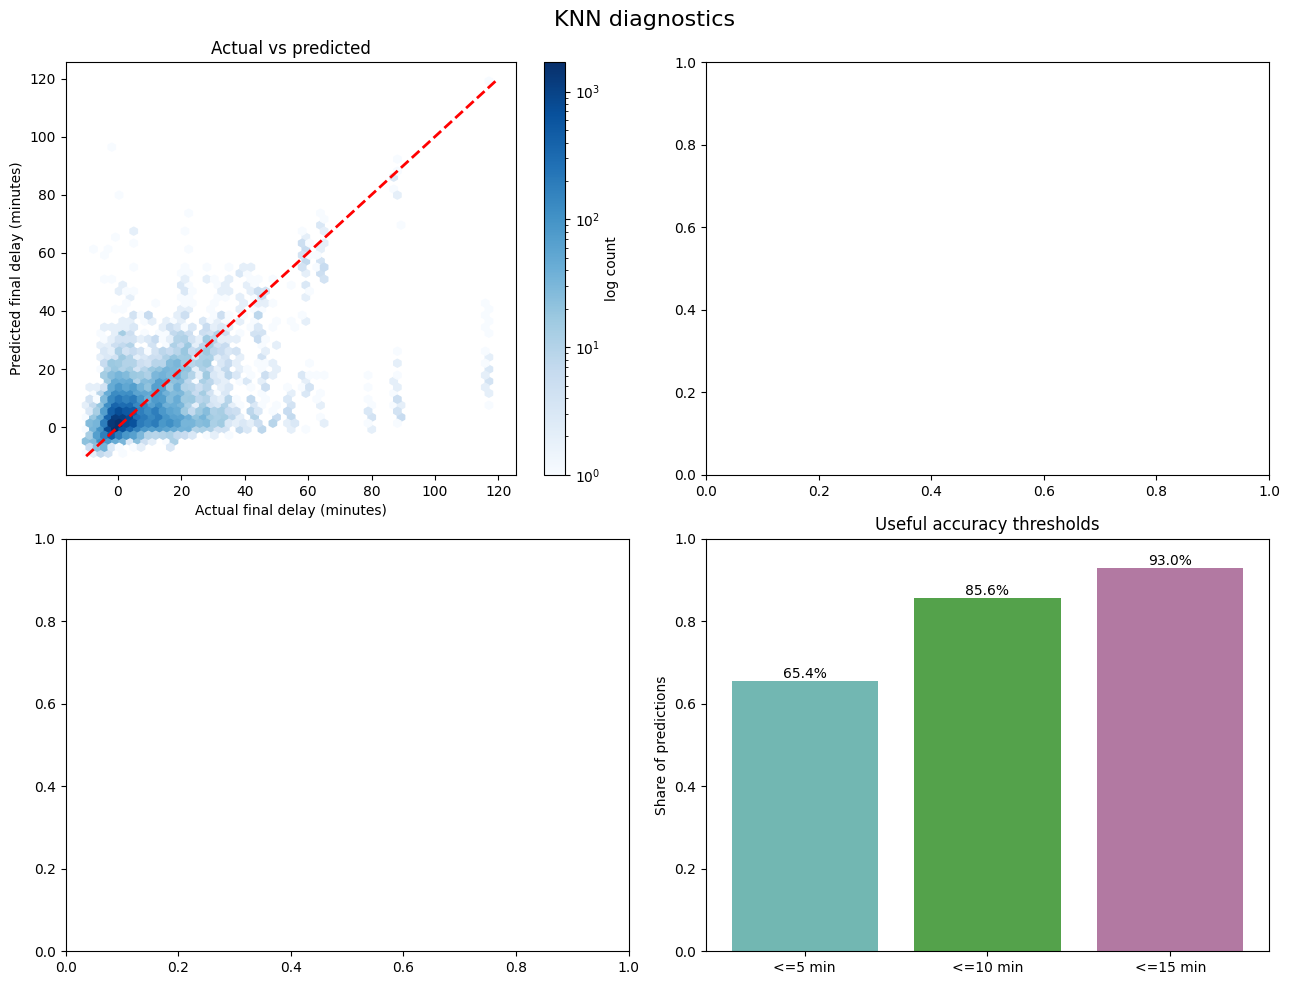

In [99]:
# KNN is distance-based, so scaling matters. Full KNN over 100k+ rows can be slow,
# so this uses a reproducible sample as a practical baseline model.
# knn_train_size = min(10_000, len(X_train))
# knn_train_index = X_train.sample(n=knn_train_size, random_state=42).index
#
# X_train_knn = X_train.loc[knn_train_index]
# y_train_knn = y_train.loc[knn_train_index]

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=7, weights="distance")),
])

knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

knn_metrics = regression_metrics("KNN", y_test, knn_pred)
model_scores.append(knn_metrics)
print(pd.Series(knn_metrics).to_string())
plot_regression_diagnostics("KNN", y_test, knn_pred)

## Train Decision Tree Model

model              Decision Tree
MAE_minutes             5.240688
RMSE_minutes            8.668296
R2                      0.320614
within_5_min            0.653961
within_10_min           0.898279
within_15_min           0.947197
large_delay_MAE        28.144089


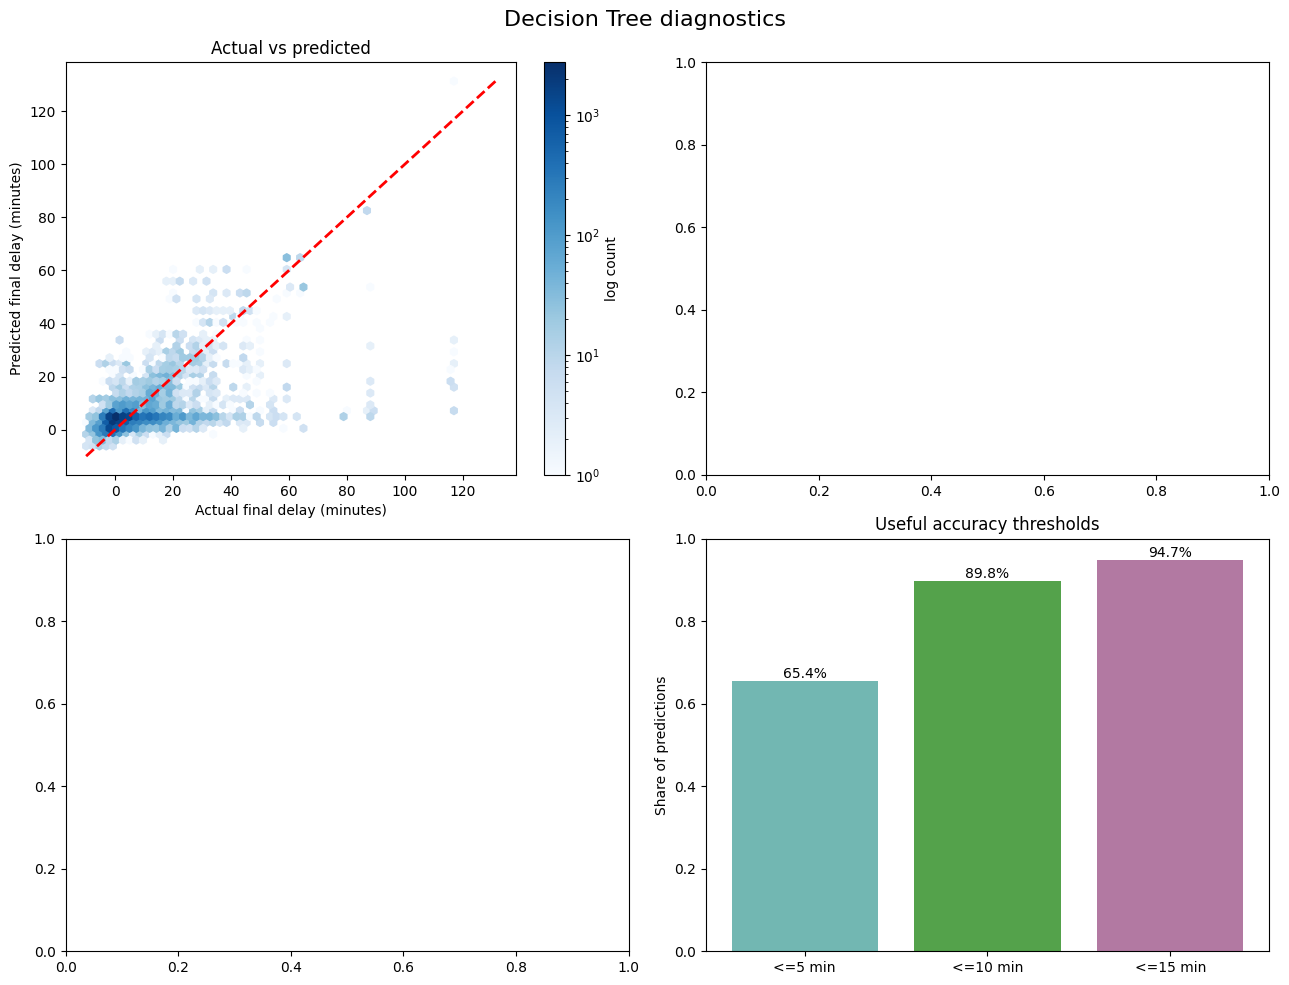

In [100]:
# Decision trees can capture non-linear station/delay interactions, but depth and
# leaf-size limits help stop the tree from memorising individual train journeys.
decision_tree_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=50,
    random_state=42,
)

decision_tree_model.fit(X_train, y_train)
decision_tree_pred = decision_tree_model.predict(X_test)

decision_tree_metrics = regression_metrics("Decision Tree", y_test, decision_tree_pred)
model_scores.append(decision_tree_metrics)
print(pd.Series(decision_tree_metrics).to_string())
plot_regression_diagnostics("Decision Tree", y_test, decision_tree_pred)

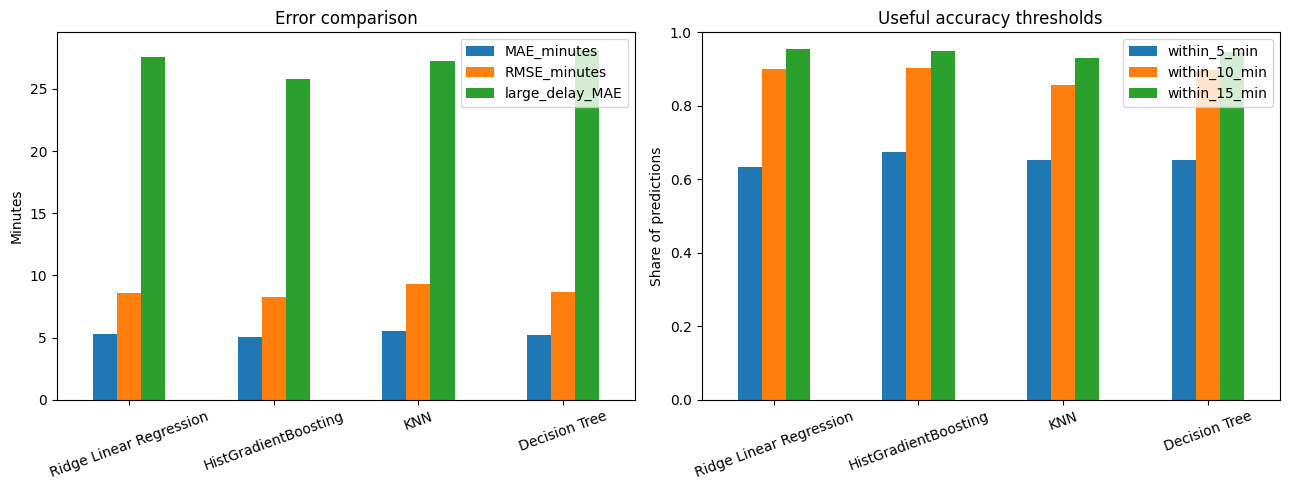

,model,MAE_minutes,RMSE_minutes,R2,within_5_min,within_10_min,within_15_min,large_delay_MAE
0,Ridge Linear Regression,5.274475,8.625703,0.327274,0.632436,0.900921,0.953841,27.562812
1,HistGradientBoosting,5.064472,8.308990,0.375768,0.674399,0.902630,0.949489,25.789294
2,KNN,5.515518,9.335784,0.211955,0.653922,0.856044,0.929751,27.231577
3,Decision Tree,5.240688,8.668296,0.320614,0.653961,0.898279,0.947197,28.144089


In [101]:
scores = pd.DataFrame(model_scores)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

scores.plot(x="model", y=["MAE_minutes", "RMSE_minutes", "large_delay_MAE"], kind="bar", ax=axes[0])
axes[0].set_ylabel("Minutes")
axes[0].set_xlabel("")
axes[0].set_title("Error comparison")
axes[0].tick_params(axis="x", rotation=20)

scores.plot(x="model", y=["within_5_min", "within_10_min", "within_15_min"], kind="bar", ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Share of predictions")
axes[1].set_xlabel("")
axes[1].set_title("Useful accuracy thresholds")
axes[1].tick_params(axis="x", rotation=20)

fig.tight_layout()
plt.show()

scores

Metric	Meaning
MAE_minutes	Average absolute prediction error in minutes

RMSE_minutes	Error in minutes, but punishes big mistakes more

R2	How much variation in final delay the model explains

within_5_min	% of predictions within 5 minutes of the real delay

within_10_min	% of predictions within 10 minutes

within_15_min	% of predictions within 15 minutes

large_delay_MAE	MAE only for large delays, e.g. actual delay >= 30 min